In [2]:
# 저장 파일 경로 변경

import os
os.chdir(r"C:\Users\luckm\멋쟁이 사자처럼[부트캠프]\파이널프로젝트")  # 여기를 실제 경로로 수정
print(os.getcwd())

C:\Users\luckm\멋쟁이 사자처럼[부트캠프]\파이널프로젝트


In [3]:
# 한글 폰트

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스(-) 깨짐 방지


###  사용 데이터(너희 조건 반영)

##### (필수)

1. (사용액)decoupling_results.csv
* gap, fin_index, real_index 포함

2. 전처리 환율: 전처리_환율.csv
* 컬럼명: exchange

3. 전처리 CPI: 전처리_cpi.csv
* 컬럼명: cpi

4. 전처리 코스피: 전처리_코스피.csv
* 컬럼명: kospi

##### (제외 조건)

1. (사용액)실물지표계산.csv, 금융지표계산.csv는 제외 (이미 decoupling에 들어있으므로)
2. 가계대출은 2008~라서 제외


# 핵심 전처리(방식 통일)

* 환율: fx_12m = log(exchange).diff(12)

* CPI: cpi_yoy = pct_change(12) * 100

---
코드 (statsmodels 없이)

아래 코드는 sklearn의 LinearRegression으로 회귀계수를 뽑고,
p-value 없이도 충분히 “논리적 검정 + 시각화 + 효과크기”로 보고서가 가능하게 구성

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# -------------------------
# 1) 데이터 로드
# -------------------------
gap = pd.read_csv("data/(사용액)decoupling_results.csv", index_col=0, parse_dates=True)
fx  = pd.read_csv("data/전처리_환율.csv", index_col=0, parse_dates=True)   # exchange
cpi = pd.read_csv("data/전처리_cpi.csv", index_col=0, parse_dates=True)   # cpi
kospi = pd.read_csv("data/전처리_코스피.csv", index_col=0, parse_dates=True)  # kospi

# -------------------------
# 2) 월 단위 정규화
# (MS 쓰면 에러났지? -> how="start"만 쓰면 됨)
# -------------------------
for d in [gap, fx, cpi, kospi]:
    d.index = pd.to_datetime(d.index)
    d.index = d.index.to_period("M").to_timestamp(how="start")

# -------------------------
# 3) 병합
# -------------------------
df = gap[["gap","fin_index","real_index"]].join(
    fx[["exchange"]], how="inner"
).join(
    cpi[["cpi"]], how="inner"
).join(
    kospi[["kospi"]], how="inner"
)

df = df.sort_index()

# -------------------------
# 4) 파생변수
# -------------------------
df["fx_12m"] = np.log(df["exchange"]).diff(12)
df["cpi_yoy"] = df["cpi"].pct_change(12) * 100

# 분석 표본 (2005년 이후)
df2 = df.dropna().copy()

print(df2.head())
print(df2.isna().sum())


                 gap  fin_index  real_index  exchange     cpi    kospi  \
date                                                                     
2006-01-01 -0.249764   0.799998    1.049762    959.87  75.231  1399.83   
2006-02-01  0.405844   0.523065    0.117221    971.00  75.381  1371.59   
2006-03-01  0.416019   0.671361    0.255343    971.60  75.827  1359.60   
2006-04-01  0.607975   0.898928    0.290953    943.20  75.902  1419.73   
2006-05-01  0.163498   0.706053    0.542555    945.70  76.050  1317.70   

              fx_12m   cpi_yoy  
date                            
2006-01-01 -0.067112  2.224366  
2006-02-01 -0.033919  2.015103  
2006-03-01 -0.046160  2.003013  
2006-04-01 -0.055573  2.000994  
2006-05-01 -0.063302  2.302994  
gap           0
fin_index     0
real_index    0
exchange      0
cpi           0
kospi         0
fx_12m        0
cpi_yoy       0
dtype: int64


##### d2 정의 

* gap : 디커플링 지수 (핵심)
* fin_index : 금융지표 합성/표준화 지수
* real_index : 실물지표 합성/표준화 지수
* exchange : 환율 (USD/KRW로 추정)
* cpi : 소비자물가지수
* kospi : 코스피 지수
* fx_12m : 환율 12개월 로그 변화 (너가 만든 파생)
* cpi_yoy : CPI YoY (너가 만든 파생)
* fx_high : 환율 고점 여부 (너가 만든 듯)

# 가설 1 (원인): 환율·구매력 훼손 가설

### 가설 구조를 “검정 가능한 형태”로 바꾸기

* 원문:

환율 상승은 실질구매력을 훼손해 소비를 위축시키는 반면, 금융시장에는 중립적 혹은 수출주 중심 강세로 작용해 디커플링을 심화시킨다.

* 이걸 3개의 테스트로 쪼갬.

1. (H1-1) 환율 상승 → 실물(real_index) 하락
* X: 환율 상승(12개월 로그변화, 또는 YoY)
* Y: 실물지표(real_index)
* 기대 부호: (-)

2. (H1-2) 환율 상승 → 금융(fin_index)은 덜 하락하거나, 오히려 상승
* X: 환율 상승
* Y: 금융지표(fin_index)
* 기대 부호: 0 또는 (+)

3. (H1-3) 환율 상승 → 디커플링(gap) 확대
* X: 환율 상승
* Y: gap
* 기대 부호: (+)

### (H1) 회귀 검정 (gap, real, fin 각각)

In [5]:
def simple_regression(y, X):
    """
    statsmodels 없이 회귀계수 추정용.
    (표준화해서 beta 비교 가능하게 함)
    """
    data = pd.concat([y, X], axis=1).dropna()
    yv = data.iloc[:, 0].values.reshape(-1, 1)
    Xv = data.iloc[:, 1:].values

    scalerX = StandardScaler()
    scalery = StandardScaler()

    Xs = scalerX.fit_transform(Xv)
    ys = scalery.fit_transform(yv).ravel()

    model = LinearRegression()
    model.fit(Xs, ys)

    coef = pd.Series(model.coef_, index=data.columns[1:])
    r2 = model.score(Xs, ys)
    return coef, r2

X = df2[["fx_12m", "cpi_yoy"]]

coef_gap, r2_gap = simple_regression(df2["gap"], X)
coef_real, r2_real = simple_regression(df2["real_index"], X)
coef_fin, r2_fin = simple_regression(df2["fin_index"], X)

print("=== gap(디커플링) ===")
print(coef_gap, "R2=", r2_gap)

print("\n=== real_index(실물) ===")
print(coef_real, "R2=", r2_real)

print("\n=== fin_index(금융) ===")
print(coef_fin, "R2=", r2_fin)


=== gap(디커플링) ===
fx_12m    -0.496498
cpi_yoy   -0.326719
dtype: float64 R2= 0.43458749615702663

=== real_index(실물) ===
fx_12m    -0.442027
cpi_yoy    0.366409
dtype: float64 R2= 0.2484384469870079

=== fin_index(금융) ===
fx_12m    -0.912310
cpi_yoy    0.013895
dtype: float64 R2= 0.826146938155697


##### 해석 기준(보고서 문장)

fx_12m 계수가

* real_index에서 **음(-)**이면 → “환율 상승이 실물을 약화”
* fin_index에서 **0 또는 양(+)**이면 → “환율 상승이 금융을 덜 약화 / 혹은 강세”
* gap에서 **양(+)**이면 → “환율 상승이 디커플링을 확대”

### H1 시각화

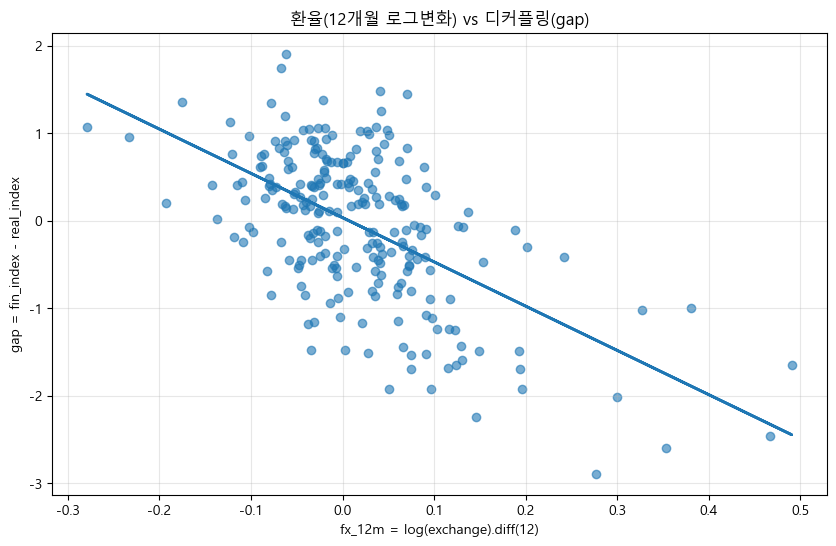

In [6]:
# 1) 환율 vs gap 산점도 + 추세선

plt.figure(figsize=(10,6))
plt.scatter(df2["fx_12m"], df2["gap"], alpha=0.6)
m, b = np.polyfit(df2["fx_12m"], df2["gap"], 1)
plt.plot(df2["fx_12m"], m*df2["fx_12m"] + b, linewidth=2)

plt.title("환율(12개월 로그변화) vs 디커플링(gap)")
plt.xlabel("fx_12m = log(exchange).diff(12)")
plt.ylabel("gap = fin_index - real_index")
plt.grid(alpha=0.3)
plt.show()


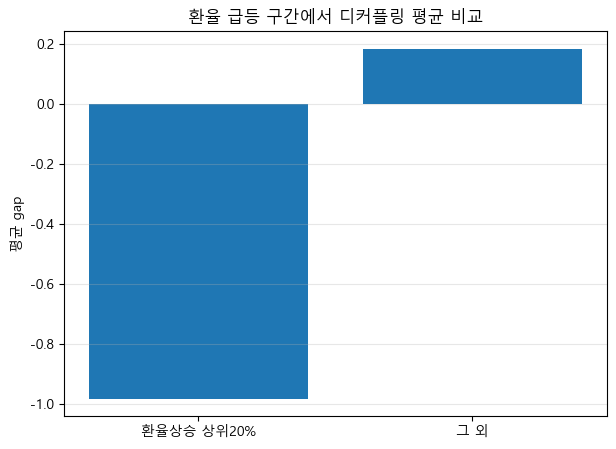

In [7]:
# 2) 환율 상승기 상위 20%에서 gap 평균 비교

q80 = df2["fx_12m"].quantile(0.80)

df2["fx_high"] = (df2["fx_12m"] >= q80).astype(int)

gap_mean_high = df2[df2["fx_high"]==1]["gap"].mean()
gap_mean_low = df2[df2["fx_high"]==0]["gap"].mean()

plt.figure(figsize=(7,5))
plt.bar(["환율상승 상위20%", "그 외"], [gap_mean_high, gap_mean_low])
plt.title("환율 급등 구간에서 디커플링 평균 비교")
plt.ylabel("평균 gap")
plt.grid(axis="y", alpha=0.3)
plt.show()

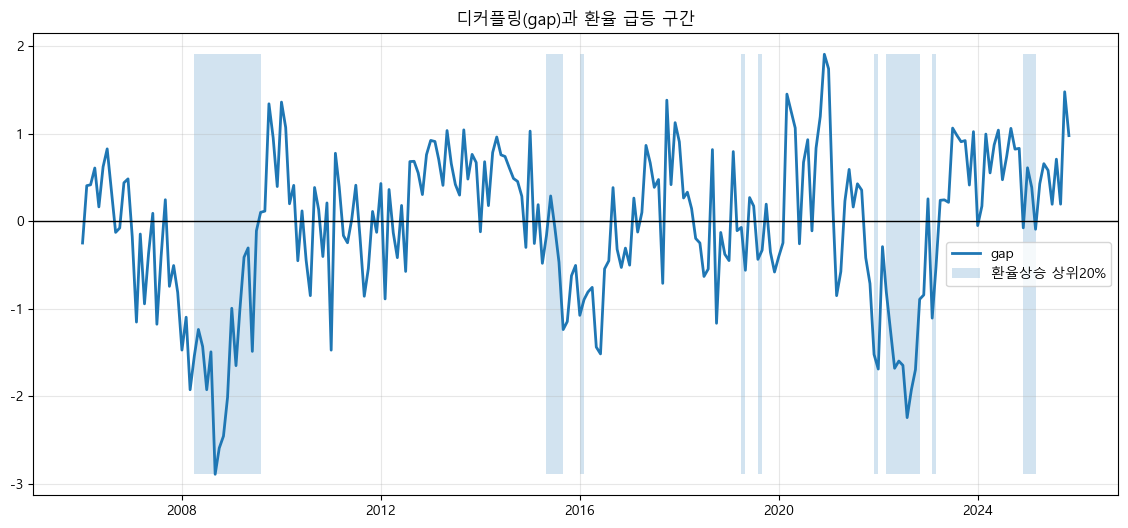

In [8]:
# 3) 시계열로 “환율 급등 구간” 음영 처리

plt.figure(figsize=(14,6))
plt.plot(df2.index, df2["gap"], label="gap", linewidth=2)
plt.axhline(0, color="black", linewidth=1)

plt.fill_between(
    df2.index,
    df2["gap"].min(), df2["gap"].max(),
    where=df2["fx_high"]==1,
    alpha=0.2,
    label="환율상승 상위20%"
)

plt.title("디커플링(gap)과 환율 급등 구간")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 가설 2 (위험성): 자산가격 불안정성
### 가설 구조

##### 디커플링 지수가 높은 구간일수록, 이후 3~6개월 내 주가 하락 확률이 증가한다.

* 핵심은 “확률”이니까 회귀가 아니라 **이벤트 기반(조정 발생 여부)**로 가야 함.

### 정의(가장 깔끔하고 보고서에 잘 들어감)

1. (1) 디커플링 high regime

* gap이 상위 10%일 때 = top_regime == True
(너희 파일에 이미 있음)

2. (2) “조정 발생” 정의

* 이후 3개월(또는 6개월) 내
KOSPI 누적수익률 < -X%
여기서 X는 보통 -5% 또는 -10%

In [11]:
# 칼럼 확인
print(df2.columns)

Index(['gap', 'fin_index', 'real_index', 'exchange', 'cpi', 'kospi', 'fx_12m',
       'cpi_yoy', 'fx_high'],
      dtype='object')


In [12]:
# top_regime / bottom_regime 생성 (gap 기준)

top10 = df2["gap"].quantile(0.90)
bot10 = df2["gap"].quantile(0.10)

df2["top_regime"] = df2["gap"] >= top10
df2["bottom_regime"] = df2["gap"] <= bot10

print("top10 threshold:", top10)
print("bot10 threshold:", bot10)


top10 threshold: 0.9360318448111292
bot10 threshold: -1.2412659204473657


In [13]:
# 코드: “3개월 / 6개월 조정 발생 확률 비교”

# kospi는 너희가 z-score 기반일 수도 있고 raw일 수도 있음
# 위험성 가설은 "조정"이므로, 반드시 raw kospi level이면 좋음
# (하지만 지금 파일이 z-score면 -> z-score 기준 하락으로 정의해도 됨)

# 여기서는 일단 kospi를 level이라고 가정하고 로그수익률로 계산
df2["kospi_ret_1m"] = np.log(df2["kospi"]).diff(1)

# 3개월 누적수익률
df2["kospi_ret_3m"] = df2["kospi_ret_1m"].rolling(3).sum().shift(-3)

# 6개월 누적수익률
df2["kospi_ret_6m"] = df2["kospi_ret_1m"].rolling(6).sum().shift(-6)

# 조정 이벤트 정의 (-5%, -10%)
df2["crash_3m_5"] = (df2["kospi_ret_3m"] <= np.log(0.95)).astype(int)
df2["crash_6m_5"] = (df2["kospi_ret_6m"] <= np.log(0.95)).astype(int)

df2["crash_3m_10"] = (df2["kospi_ret_3m"] <= np.log(0.90)).astype(int)
df2["crash_6m_10"] = (df2["kospi_ret_6m"] <= np.log(0.90)).astype(int)


In [14]:
# 확률 비교 (top_regime vs 나머지)

def event_prob(df, event_col):
    p_top = df[df["top_regime"]==True][event_col].mean()
    p_else = df[df["top_regime"]==False][event_col].mean()
    return p_top, p_else

for col in ["crash_3m_5","crash_6m_5","crash_3m_10","crash_6m_10"]:
    p_top, p_else = event_prob(df2.dropna(), col)
    print(col, "TopRegime=", round(p_top,3), "Else=", round(p_else,3))

crash_3m_5 TopRegime= 0.136 Else= 0.2
crash_6m_5 TopRegime= 0.182 Else= 0.257
crash_3m_10 TopRegime= 0.045 Else= 0.086
crash_6m_10 TopRegime= 0.045 Else= 0.138


해석(보고서 문장)

TopRegime 확률이 더 높으면
→ “디커플링이 큰 구간에서 이후 조정 위험이 더 큼”

### 시각화

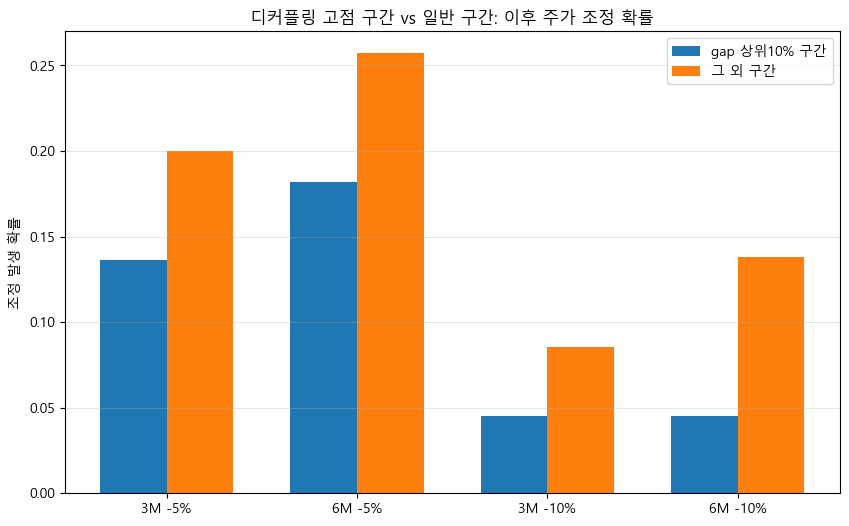

In [ ]:
# 1: 조정 확률 막대그래프(3m/6m)

events = ["crash_3m_5","crash_6m_5","crash_3m_10","crash_6m_10"]
labels = ["3M -5%","6M -5%","3M -10%","6M -10%"]

top_probs = []
else_probs = []

for e in events:
    p_top, p_else = event_prob(df2.dropna(), e)
    top_probs.append(p_top)
    else_probs.append(p_else)

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, top_probs, width, label="gap 상위10% 구간")
plt.bar(x + width/2, else_probs, width, label="그 외 구간")

plt.xticks(x, labels)
plt.ylabel("조정 발생 확률")
plt.title("디커플링 고점 구간 vs 일반 구간: 이후 주가 조정 확률")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

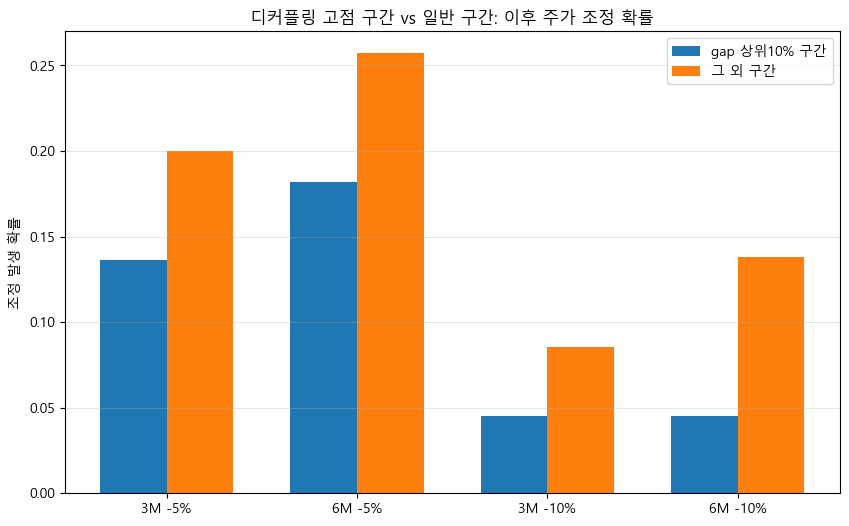

In [23]:
# 2: 시계열 + 디커플링 상위10% 음영 + 이후 수익률 표시

events = ["crash_3m_5","crash_6m_5","crash_3m_10","crash_6m_10"]
labels = ["3M -5%","6M -5%","3M -10%","6M -10%"]

top_probs = []
else_probs = []

for e in events:
    p_top, p_else = event_prob(df2.dropna(), e)
    top_probs.append(p_top)
    else_probs.append(p_else)

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, top_probs, width, label="gap 상위10% 구간")
plt.bar(x + width/2, else_probs, width, label="그 외 구간")

plt.xticks(x, labels)
plt.ylabel("조정 발생 확률")
plt.title("디커플링 고점 구간 vs 일반 구간: 이후 주가 조정 확률")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()



In [19]:
# 2: 시계열 + 디커플링 상위10% 음영 + 이후 수익률 표시

dfA = df2.dropna().copy()

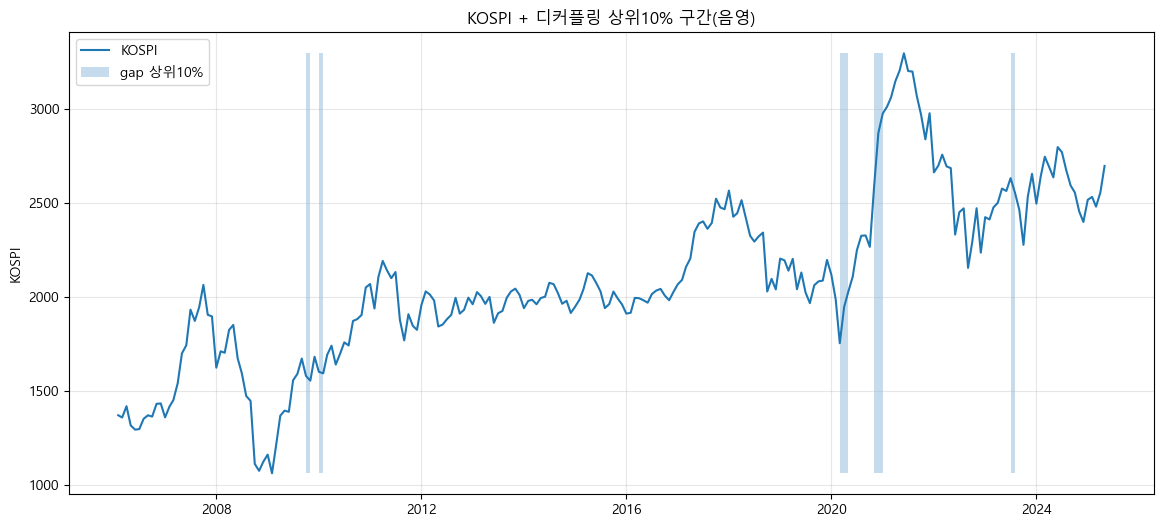

In [20]:
# (그림1) KOSPI 시계열 + 디커플링 상위10% 구간 음영

plt.figure(figsize=(14,6))

plt.plot(dfA.index, dfA["kospi"], label="KOSPI")

mask = dfA["top_regime"] == True
plt.fill_between(
    dfA.index,
    dfA["kospi"].min(),
    dfA["kospi"].max(),
    where=mask,
    alpha=0.25,
    label="gap 상위10%"
)

plt.title("KOSPI + 디커플링 상위10% 구간(음영)")
plt.ylabel("KOSPI")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

“디커플링 고점 구간이 언제였는지”를 시각적으로 보여주는 베이스 플롯이야.

### (그림2) “상위10% 진입 시점”마다 3개월/6개월 이후 수익률 표시

여기서 핵심은:

* 상위10% 구간은 보통 몇 달 연속으로 이어짐
* 그럼 이벤트가 너무 많아져서 그래프가 난잡해짐
* 그래서 **상위10% ‘진입 시점’(False→True)**만 이벤트로 잡는 게 깔끔함

In [21]:
# (1) 상위10% “진입 이벤트” 만들기

dfA["top_entry"] = (dfA["top_regime"] == True) & (dfA["top_regime"].shift(1) == False)


In [22]:
# (2) 진입 이벤트마다 3M / 6M 이후 수익률 계산

event_dates = dfA.index[dfA["top_entry"] == True]

rows = []
for d in event_dates:
    if d in dfA.index:
        r3 = dfA.loc[d, "kospi_ret_3m"]
        r6 = dfA.loc[d, "kospi_ret_6m"]
        rows.append([d, r3, r6])

event_df = pd.DataFrame(rows, columns=["date","ret_3m","ret_6m"]).set_index("date")
event_df = event_df.dropna()
print(event_df.head())

              ret_3m    ret_6m
date                          
2009-10-01  0.013660  0.096920
2010-01-01  0.083260  0.093412
2013-05-01 -0.038040  0.021662
2013-09-01  0.007175 -0.005700
2014-05-01  0.036219 -0.007133


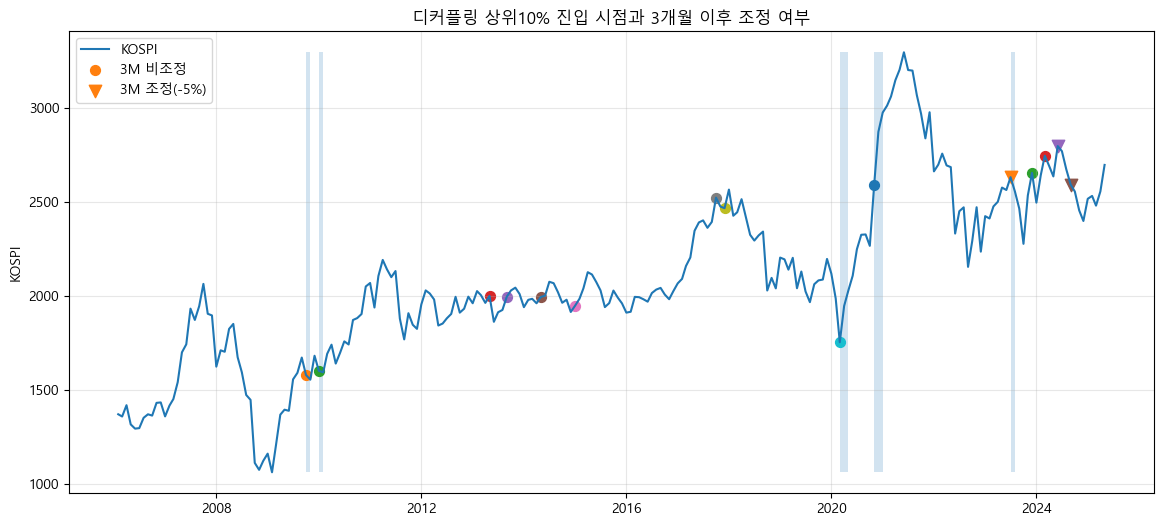

In [24]:
# (3) KOSPI + 이벤트 이후수익률을 점으로 표시
# 3개월 후 수익률이 -5% 이하인 경우: 아래쪽에 빨간 점
# 아니면: 위쪽에 파란 점

plt.figure(figsize=(14,6))
plt.plot(dfA.index, dfA["kospi"], label="KOSPI")

# 음영
mask = dfA["top_regime"] == True
plt.fill_between(dfA.index, dfA["kospi"].min(), dfA["kospi"].max(),
                 where=mask, alpha=0.2)

# 이벤트 마커 찍기
for d in event_df.index:
    # 3개월 이후 누적수익률
    r3 = event_df.loc[d, "ret_3m"]
    # 조건: -5% 이하 조정
    if r3 <= np.log(0.95):
        plt.scatter(d, dfA.loc[d, "kospi"], marker="v", s=80, label="3M 조정(-5%)" if "3M 조정(-5%)" not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.scatter(d, dfA.loc[d, "kospi"], marker="o", s=50, label="3M 비조정" if "3M 비조정" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title("디커플링 상위10% 진입 시점과 3개월 이후 조정 여부")
plt.ylabel("KOSPI")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


이 그림은 보고서에서 **“디커플링 고점 진입 → 이후 조정 발생”**을 직관적으로 보여줌.

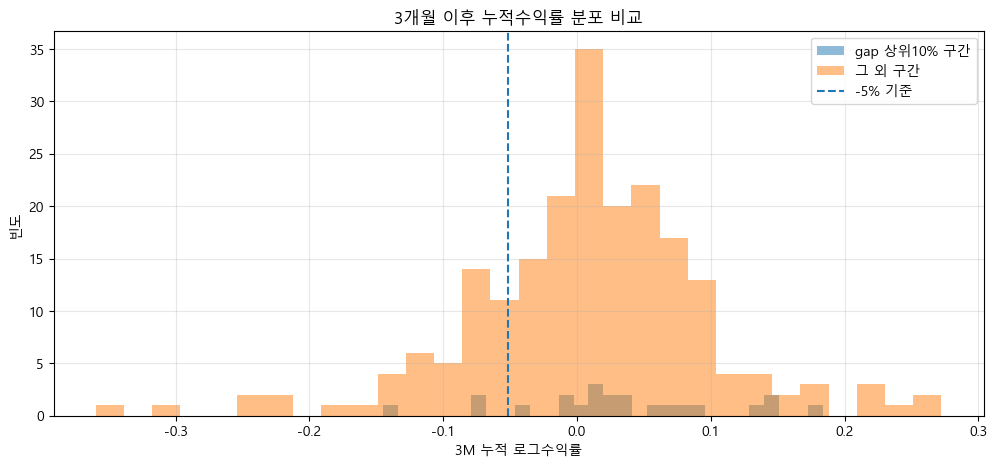

In [25]:
# 그림3) “이벤트 이후수익률 분포” 비교 (Top vs Else)
# 이건 위험성 가설을 시각적으로 가장 설득력 있게 만드는 그림이야.

# Top regime vs Else의 3개월 이후수익률 분포

top_ret3 = dfA.loc[dfA["top_regime"]==True, "kospi_ret_3m"].dropna()
else_ret3 = dfA.loc[dfA["top_regime"]==False, "kospi_ret_3m"].dropna()

plt.figure(figsize=(12,5))
plt.hist(top_ret3, bins=30, alpha=0.5, label="gap 상위10% 구간")
plt.hist(else_ret3, bins=30, alpha=0.5, label="그 외 구간")

plt.axvline(np.log(0.95), linestyle="--", label="-5% 기준")
plt.title("3개월 이후 누적수익률 분포 비교")
plt.xlabel("3M 누적 로그수익률")
plt.ylabel("빈도")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


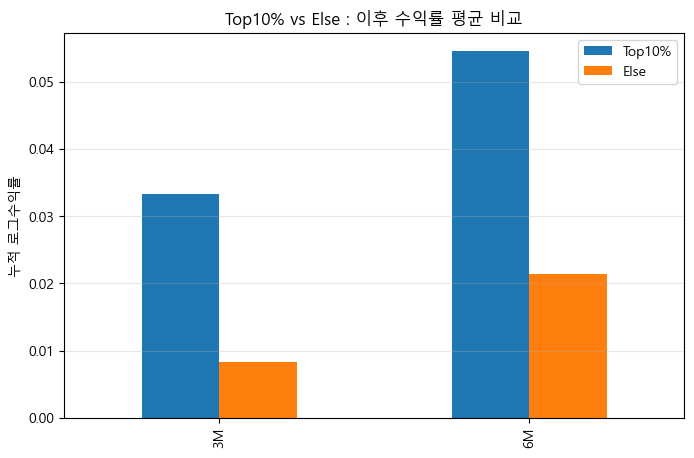

In [26]:
# (그림4) 이벤트 이후 수익률 “평균” 비교 (3M / 6M)

means = pd.DataFrame({
    "Top10%": [
        dfA.loc[dfA["top_regime"]==True, "kospi_ret_3m"].mean(),
        dfA.loc[dfA["top_regime"]==True, "kospi_ret_6m"].mean()
    ],
    "Else": [
        dfA.loc[dfA["top_regime"]==False, "kospi_ret_3m"].mean(),
        dfA.loc[dfA["top_regime"]==False, "kospi_ret_6m"].mean()
    ]
}, index=["3M","6M"])

means.plot(kind="bar", figsize=(8,5))
plt.title("Top10% vs Else : 이후 수익률 평균 비교")
plt.ylabel("누적 로그수익률")
plt.grid(axis="y", alpha=0.3)
plt.show()